In [1]:
# Persiapan tambahan, bukan listing buku.
import sys
import numpy as np
import matplotlib
import matplotlib.pyplot as plt

np.set_printoptions(precision=8, suppress=True)
plt.rcParams.update({
    'font.size': 11,
    'axes.spines.top': False,
    'axes.spines.right': False,
})
print('Python:', sys.version.split()[0])
print('NumPy:', np.__version__)
print('Matplotlib:', matplotlib.__version__)
print('Runtime CPU; data inti dan pola sintetis tersedia langsung di notebook.')

Python: 3.13.16
NumPy: 2.1.3
Matplotlib: 3.10.0
Runtime CPU; data inti dan pola sintetis tersedia langsung di notebook.


## 2. Ringkasan Chapter 5

Chapter 5 menunjukkan bahwa aturan pembaruan bobot dari bab sebelumnya dapat digunakan pada jaringan dengan banyak koneksi. Untuk banyak input dan satu output, prediksi adalah weighted sum. Seluruh bobot menuju output tersebut berbagi satu residual, tetapi setiap gradien berbeda karena residual dikalikan nilai input yang bersesuaian.

Perbedaan skala input membuat besar update tidak merata. Input yang besar dapat menghasilkan gradien besar dan memerlukan learning rate lebih kecil. Eksperimen membekukan bobot memperlihatkan bahwa bobot lain masih dapat menurunkan loss. Pada satu observasi, beberapa kombinasi bobot dapat menghasilkan prediksi yang sama; error nol tidak menentukan satu konfigurasi bobot yang unik.

Untuk satu input dan banyak output, setiap output mempunyai residual sendiri, sedangkan semua gradien memakai input yang sama. Ketika input dan output sama-sama banyak, bobot disusun dalam matriks. Gradien setiap koneksi diperoleh dengan mengalikan residual output dan input pada koneksi tersebut, sehingga terbentuk outer product.

Bagian akhir memperkenalkan MNIST sebagai contoh gambar dengan 784 input dan 10 keluaran. Gambar dapat diubah menjadi vektor, sedangkan bobot menuju satu kelas dapat dibentuk kembali menjadi gambar untuk inspeksi. Dot product menjelaskan mengapa pola pixel tertentu menghasilkan skor tinggi atau rendah. Visualisasi membantu memahami kontribusi bobot, tetapi bobot linear dan skor keluaran belum otomatis menjadi korelasi statistik atau probabilitas.

**Rujukan:** Trask (2019), hlm. 79-98.

## 3. Peta subbab dan reproduksi

| Subbab buku | Halaman cetak | Pengerjaan notebook |
| --- | --- | --- |
| Gradient descent learning with multiple inputs | 80-81 | Satu iterasi dengan tiga input |
| Gradient descent with multiple inputs explained | 82-85 | Shared delta, gradien per input, dan perbandingan satu input |
| Let's watch several steps of learning | 86-87 | Reproduksi tiga iterasi; percobaan alpha 0,1 |
| Freezing one weight: What does it do? | 88-89 | Reproduksi tiga iterasi dengan bobot pertama dibekukan |
| Gradient descent learning with multiple outputs | 90-91 | Satu input, tiga output, dan update yang dikoreksi |
| Gradient descent with multiple inputs and outputs | 92-93 | Matriks bobot, outer product, dan update lengkap |
| What do these weights learn? | 94-95 | MNIST, flattening, one-hot, dan shape 784 ke 10 |
| Visualizing weight values | 96 | Peta bobot contoh dan arti tanda bobot |
| Visualizing dot products (weighted sums) | 97 | Reproduksi vektor, hasil dot product, dan visualisasi |
| Summary | 98 | Fleksibilitas gradient descent dan kesiapan menuju Chapter 6 |

Listing yang berulang pada diagram hlm. 82-85 digabung dengan contoh lengkap hlm. 80-81. Definisi helper yang sama pada hlm. 86 dan 88 digunakan kembali. Bagian MNIST pada hlm. 94-97 berisi pengantar dan visualisasi konseptual, bukan listing pelatihan MNIST lengkap. Ilustrasi sintetis di notebook merupakan tambahan untuk memahami operasi tersebut.

## 4. Dasar teori: residual, loss, dan gradien

Untuk vektor input $\mathbf{x}\in\mathbb{R}^n$ dan bobot $\mathbf{w}\in\mathbb{R}^n$ menuju satu output:

$$\hat{y}=\mathbf{x}^{T}\mathbf{w}=\sum_{i=1}^{n}x_iw_i$$

Residual output adalah $\delta=\hat{y}-y$. Seperti Chapter 4, buku menampilkan squared error $E=\delta^2$, tetapi aturan update menggunakan gradien dari **half squared error** $J=\tfrac12\delta^2$:

$$\frac{\partial J}{\partial w_i}=\delta x_i,
\qquad w_i\leftarrow w_i-\alpha\delta x_i$$

Turunan squared error penuh bernilai $2\delta x_i$. Faktor dua dapat diserap ke learning rate, tetapi definisi loss dan gradien harus konsisten. Reproduksi mempertahankan rumus update buku.

| Besaran | Arti | Hubungan dengan update |
| --- | --- | --- |
| `delta` | Residual pada satu output | Dapat dipakai bersama oleh beberapa koneksi ke output itu |
| `weight_deltas[i]` | Gradien half squared error terhadap bobot ke-i | `delta * input_data[i]` |
| Perubahan bobot aktual | Selisih bobot baru dengan bobot lama | `-alpha * weight_deltas[i]` |

Semua gradien dalam satu langkah dihitung dari prediksi dan bobot sebelum update. Bobot kemudian diperbarui dengan gradien tersebut. Dengan cara ini, loop update beberapa bobot tetap merupakan satu langkah gradient descent yang serentak secara matematis.

**Rujukan:** Trask (2019), hlm. 80-85; klarifikasi notasi half squared loss melanjutkan pendalaman Chapter 4.

## 5. Gradient descent learning with multiple inputs

**Asal kode:** reproduksi gabungan hlm. 80-81, mencakup listing yang diulang pada hlm. 82-85. Model memakai tiga feature dari pertandingan pertama: `toes = 8.5`, `wlrec = 0.65`, dan `nfans = 1.2`, dengan target `1`.

Bobot awal `[0.1, 0.2, -0.1]` menghasilkan prediksi:

$$8.5(0.1)+0.65(0.2)+1.2(-0.1)=0.86$$

Residualnya `-0.14` dan squared error `0.0196`. Gradien setiap bobot adalah `[-1.19, -0.091, -0.168]`. Dengan alpha `0.01`, bobot baru menjadi `[0.1119, 0.20091, -0.09832]`.

**Penyesuaian:** dua pemanggilan pada hlm. 81 menggunakan `weight` walaupun bobot disimpan dalam `weights`; notebook menggunakan `weights`. Beberapa tanda atau pembulatan pada diagram hlm. 82-85 tidak cocok dengan formula. Hasil numerik notebook mengikuti `delta = pred - true`, sehingga delta untuk contoh ini negatif.

Helper `ele_mul` tetap menggunakan tiga elemen, mengikuti buku. Generalisasi helper untuk jumlah input/output berbeda dibahas setelah contoh matriks.

In [2]:
# Reproduksi gabungan hlm. 80-85; weight -> weights pada pemanggilan yang salah ketik.
def w_sum(a, b):
    assert len(a) == len(b)
    output = 0
    for i in range(len(a)):
        output += a[i] * b[i]
    return output

def ele_mul(number, vector):
    output = [0, 0, 0]
    assert len(output) == len(vector)
    for i in range(len(vector)):
        output[i] = number * vector[i]
    return output

weights = [0.1, 0.2, -0.1]

def neural_network(input_data, weights):
    pred = w_sum(input_data, weights)
    return pred

toes = [8.5, 9.5, 9.9, 9.0]
wlrec = [0.65, 0.8, 0.8, 0.9]
nfans = [1.2, 1.3, 0.5, 1.0]
win_or_lose_binary = [1, 1, 0, 1]
true = win_or_lose_binary[0]
input_data = [toes[0], wlrec[0], nfans[0]]

pred = neural_network(input_data, weights)
error = (pred - true) ** 2
delta = pred - true
weight_deltas = ele_mul(delta, input_data)
alpha = 0.01

initial_multi_weights = weights.copy()
initial_multi_input = input_data.copy()
multi_input_step = {
    'prediction': pred, 'error': error, 'delta': delta,
    'gradients': weight_deltas.copy(),
}
for i in range(len(weights)):
    weights[i] -= alpha * weight_deltas[i]

multi_input_step['new_weights'] = weights.copy()
print('Prediction sebelum update:', pred)
print('Error sebelum update:', error)
print('Delta:', delta)
print('Weights:' + str(weights))
print('Weight Deltas:' + str(weight_deltas))
print('Prediction sesudah update:', neural_network(input_data, weights))
print('Error sesudah update:', (neural_network(input_data, weights) - true) ** 2)

Prediction sebelum update: 0.8600000000000001
Error sebelum update: 0.01959999999999997
Delta: -0.1399999999999999
Weights:[0.1119, 0.20091, -0.09832]
Weight Deltas:[-1.189999999999999, -0.09099999999999994, -0.16799999999999987]
Prediction sesudah update: 0.9637574999999999
Error sesudah update: 0.0013135188062500048


## 6. Mengapa satu delta menghasilkan tiga gradien?

Output tunggal hanya mempunyai satu residual. Setiap bobot memengaruhi output melalui input yang berbeda, sehingga turunan output terhadap bobot ke-i adalah $x_i$. Aturan rantai memberikan gradien $\delta x_i$ untuk setiap koneksi.

Tiga sifat dari Chapter 4 tetap berlaku: input nol membuat gradien bobot itu nol; input negatif membalik pengaruh perubahan bobot terhadap prediksi; input besar memperbesar sensitivitas dan besar gradien pada residual yang sama.

| Feature | Input | Residual bersama | Gradien bobot | Perubahan bobot, alpha 0,01 |
| --- | --- | --- | --- | --- |
| `toes` | $8.5$ | $-0.14$ | $-1.19$ | $+0.0119$ |
| `wlrec` | $0.65$ | $-0.14$ | $-0.091$ | $+0.00091$ |
| `nfans` | $1.2$ | $-0.14$ | $-0.168$ | $+0.00168$ |

Bobot dengan gradien besar mengalami update lebih besar. Namun, besar update juga dipengaruhi satuan feature; hal itu tidak otomatis menunjukkan bahwa feature tersebut paling penting atau mempunyai pengaruh kausal terbesar.

### Perbandingan dengan satu input

Contoh satu input yang diulang pada hlm. 82-85 memakai `8.5`, bobot `0.1`, dan target `1`. Prediksinya `0.85`, residual `-0.15`, dan gradien tepatnya `-1.275`. Diagram hlm. 84 menulis `8.5 * -0.15 = -1.25`; hasil aritmetika sebenarnya adalah `-1.275`. Maka bobot baru untuk alpha `0.01` adalah `0.11275`.

**Rujukan:** Trask (2019), hlm. 82-85.

In [3]:
# Reproduksi gabungan perhitungan satu input pada hlm. 82, 84, dan 85.
single_weight = 0.1
single_input = 8.5
single_true = 1
single_pred = single_input * single_weight
single_error = (single_pred - single_true) ** 2
single_delta = single_pred - single_true
single_gradient = single_input * single_delta
single_weight -= 0.01 * single_gradient
print('Prediction:', single_pred)
print('Error:', single_error)
print('Delta:', single_delta)
print('Weight delta:', single_gradient)
print('Weight baru:', single_weight)

Prediction: 0.8500000000000001
Error: 0.022499999999999975
Delta: -0.1499999999999999
Weight delta: -1.2749999999999992
Weight baru: 0.11275


## 7. Let's watch several steps of learning

**Asal kode:** reproduksi hlm. 86. Nilai awal dan tiga iterasi dipertahankan. Variabel loop `iter` ditulis sebagai `iteration`; pencatatan history ditambahkan.

Log mencetak bobot, prediksi, residual, dan gradien **sebelum update**. Bobot akhir dihitung terpisah. Tiga prediksi awal mendekati target `1`, dari `0.86` menuju sekitar `0.96376` dan `0.99062`.

Alpha `0.01` cukup kecil untuk contoh ini. Halaman 87 meminta mencoba alpha `0.1`; eksperimen tersebut diberikan di bagian berikutnya.

**Rujukan:** Trask (2019), hlm. 86-87.

In [4]:
# Reproduksi hlm. 86.
def neural_network(input_data, weights):
    out = 0
    for i in range(len(input_data)):
        out += input_data[i] * weights[i]
    return out

def ele_mul(scalar, vector):
    out = [0, 0, 0]
    for i in range(len(out)):
        out[i] = vector[i] * scalar
    return out

toes = [8.5, 9.5, 9.9, 9.0]
wlrec = [0.65, 0.8, 0.8, 0.9]
nfans = [1.2, 1.3, 0.5, 1.0]
win_or_lose_binary = [1, 1, 0, 1]
true = win_or_lose_binary[0]
alpha = 0.01
weights = [0.1, 0.2, -0.1]
input_data = [toes[0], wlrec[0], nfans[0]]
multi_three_history = []

for iteration in range(3):
    pred = neural_network(input_data, weights)
    error = (pred - true) ** 2
    delta = pred - true
    weight_deltas = ele_mul(delta, input_data)
    multi_three_history.append({
        'iteration': iteration, 'weights': weights.copy(),
        'prediction': pred, 'error': error, 'gradient': weight_deltas.copy(),
    })
    print('Iteration:' + str(iteration + 1))
    print('Pred:' + str(pred))
    print('Error:' + str(error))
    print('Delta:' + str(delta))
    print('Weights:' + str(weights))
    print('Weight_Deltas:')
    print(str(weight_deltas))
    print()
    for i in range(len(weights)):
        weights[i] -= alpha * weight_deltas[i]

multi_three_final = weights.copy()
print('Bobot sesudah 3 update:', multi_three_final)
print('Prediksi sesudah 3 update:', neural_network(input_data, weights))
print('Error sesudah 3 update:', (neural_network(input_data, weights) - true) ** 2)

Iteration:1
Pred:0.8600000000000001
Error:0.01959999999999997
Delta:-0.1399999999999999
Weights:[0.1, 0.2, -0.1]
Weight_Deltas:
[-1.189999999999999, -0.09099999999999994, -0.16799999999999987]

Iteration:2
Pred:0.9637574999999999
Error:0.0013135188062500048
Delta:-0.036242500000000066
Weights:[0.1119, 0.20091, -0.09832]
Weight_Deltas:
[-0.30806125000000056, -0.023557625000000044, -0.04349100000000008]

Iteration:3
Pred:0.9906177228125002
Error:8.802712522307997e-05
Delta:-0.009382277187499843
Weights:[0.11498061250000001, 0.20114557625, -0.09788509000000001]
Weight_Deltas:
[-0.07974935609374867, -0.006098480171874899, -0.011258732624999811]

Bobot sesudah 3 update: [0.1157781060609375, 0.20120656105171877, -0.09777250267375001]
Prediksi sesudah 3 update: 0.997571162993086
Error sesudah 3 update: 5.899249206154892e-06


## 8. Eksperimen alpha 0,1 dan skala feature

**Asal kode berikut:** tambahan untuk percobaan yang diminta pada hlm. 87. Helper NumPy memakai aturan update yang sama dengan reproduksi list. Fungsi juga menerima mask agar dapat digunakan untuk analisis pembekuan bobot.

Untuk satu observasi, residual setelah update mengikuti:

$$\delta_{t+1}=\bigl(1-\alpha\|\mathbf{x}\|^2\bigr)\delta_t$$

Pada input buku, $\|\mathbf{x}\|^2=8.5^2+0.65^2+1.2^2=74.1125$. Faktor residual untuk alpha `0.01` adalah `0.258875`; untuk alpha `0.1`, faktornya `-6.41125`. Faktor kedua mempunyai besar lebih dari satu, sehingga residual berganti tanda dan membesar.

Input `toes` mendominasi kuadrat norma karena nilainya besar. Normalisasi atau standardisasi feature dapat membantu mengurangi perbedaan skala dalam praktik, tetapi harus dilakukan secara konsisten berdasarkan data training. Mengubah skala feature juga mengubah interpretasi bobot; sekadar membandingkan besar bobot antar feature yang satuannya berbeda dapat menyesatkan.

Derivasi kondisi stabilitas yang lebih lengkap diberikan di bagian 11.

In [5]:
# Helper eksperimen tambahan; tidak menggantikan listing buku.
def train_one_observation(input_data, target, initial_weights, alpha, updates, mask=None):
    x_vector = np.asarray(input_data, dtype=float)
    weights = np.asarray(initial_weights, dtype=float).copy()
    trainable = np.ones_like(weights) if mask is None else np.asarray(mask, dtype=float)
    assert x_vector.shape == weights.shape == trainable.shape
    history = []
    for step in range(updates + 1):
        prediction = x_vector @ weights
        residual = prediction - target
        raw_gradient = residual * x_vector
        applied_gradient = raw_gradient * trainable
        history.append({
            'step': step, 'weights': weights.copy(), 'prediction': prediction,
            'delta': residual, 'error': residual ** 2,
            'raw_gradient': raw_gradient.copy(), 'applied_gradient': applied_gradient.copy(),
        })
        if step < updates:
            weights -= alpha * applied_gradient
    return history

stable_trace = train_one_observation(initial_multi_input, 1, initial_multi_weights, 0.01, 12)
unstable_trace = train_one_observation(initial_multi_input, 1, initial_multi_weights, 0.1, 12)
print('Kuadrat norma input:', np.dot(initial_multi_input, initial_multi_input))
print('Alpha | Langkah | Prediction | Error')
for alpha_value, trace in [(0.01, stable_trace), (0.1, unstable_trace)]:
    for row in trace[:4]:
        print(f"{alpha_value:5.2f} | {row['step']:7d} | {row['prediction']:10.6f} | {row['error']:.6e}")
    print(f"Error setelah 12 update, alpha {alpha_value}: {trace[-1]['error']:.6e}")

Kuadrat norma input: 74.1125
Alpha | Langkah | Prediction | Error
 0.01 |       0 |   0.860000 | 1.960000e-02
 0.01 |       1 |   0.963757 | 1.313519e-03
 0.01 |       2 |   0.990618 | 8.802713e-05
 0.01 |       3 |   0.997571 | 5.899249e-06
Error setelah 12 update, alpha 0.01: 1.608491e-16
 0.10 |       0 |   0.860000 | 1.960000e-02
 0.10 |       1 |   1.897575 | 8.056409e-01
 0.10 |       2 |  -4.754578 | 3.311516e+01
 0.10 |       3 |  37.894036 | 1.361170e+03
Error setelah 12 update, alpha 0.1: 4.559121e+17


## 9. Freezing one weight: What does it do?

**Asal kode:** reproduksi hlm. 88. Bobot pertama tetap `0.1`, sementara bobot kedua dan ketiga diperbarui dengan alpha `0.3`. Helper `neural_network` dan `ele_mul` digunakan kembali dari reproduksi hlm. 86 karena definisinya sama.

Baris `weight_deltas[0] = 0` menonaktifkan update pada bobot pertama. Ini adalah **mask terhadap gradien yang diterapkan**, bukan bukti bahwa turunan loss terhadap bobot tersebut memang nol. Sampai residual mendekati nol, gradien mentah untuk bobot pertama masih dapat bernilai bukan nol.

Bobot kedua dan ketiga dapat mengurangi residual output yang sama. Karena loss dibagi oleh semua koneksi ke output tersebut, loss tetap dapat turun meskipun satu parameter dipertahankan. Setelah tiga iterasi, error mengecil tetapi belum nol persis.

**Rujukan:** Trask (2019), hlm. 88-89.

In [6]:
# Reproduksi hlm. 88; helper identik digunakan kembali dari bagian 7.
toes = [8.5, 9.5, 9.9, 9.0]
wlrec = [0.65, 0.8, 0.8, 0.9]
nfans = [1.2, 1.3, 0.5, 1.0]
win_or_lose_binary = [1, 1, 0, 1]
true = win_or_lose_binary[0]
alpha = 0.3
weights = [0.1, 0.2, -0.1]
input_data = [toes[0], wlrec[0], nfans[0]]
frozen_three_history = []

for iteration in range(3):
    pred = neural_network(input_data, weights)
    error = (pred - true) ** 2
    delta = pred - true
    weight_deltas = ele_mul(delta, input_data)
    raw_gradient = weight_deltas.copy()
    weight_deltas[0] = 0
    frozen_three_history.append({
        'iteration': iteration, 'weights': weights.copy(), 'prediction': pred,
        'error': error, 'raw_gradient': raw_gradient,
        'applied_gradient': weight_deltas.copy(),
    })
    print('Iteration:' + str(iteration + 1))
    print('Pred:' + str(pred))
    print('Error:' + str(error))
    print('Delta:' + str(delta))
    print('Weights:' + str(weights))
    print('Weight_Deltas:')
    print(str(weight_deltas))
    print()
    for i in range(len(weights)):
        weights[i] -= alpha * weight_deltas[i]

frozen_three_final = weights.copy()
print('Bobot setelah 3 update:', frozen_three_final)
print('Prediksi setelah 3 update:', neural_network(input_data, weights))
print('Error setelah 3 update:', (neural_network(input_data, weights) - true) ** 2)

Iteration:1
Pred:0.8600000000000001
Error:0.01959999999999997
Delta:-0.1399999999999999
Weights:[0.1, 0.2, -0.1]
Weight_Deltas:
[0, -0.09099999999999994, -0.16799999999999987]

Iteration:2
Pred:0.9382250000000001
Error:0.003816150624999989
Delta:-0.06177499999999991
Weights:[0.1, 0.2273, -0.04960000000000005]
Weight_Deltas:
[0, -0.040153749999999946, -0.07412999999999989]

Iteration:3
Pred:0.97274178125
Error:0.000743010489422852
Delta:-0.027258218750000007
Weights:[0.1, 0.239346125, -0.02736100000000008]
Weight_Deltas:
[0, -0.017717842187500006, -0.032709862500000006]

Bobot setelah 3 update: [0.1, 0.24466147765625, -0.017548041250000077]
Prediksi setelah 3 update: 0.9879723109765626
Error setelah 3 update: 0.00014466530324451716


## 10. Mengapa kurva error dapat bergeser ketika bobot dibekukan?

Dengan bobot pertama tetap, prediksi menjadi $8.5(0.1)+0.65w_1+1.2w_2$. Dua bobot yang masih aktif dapat menghasilkan kontribusi yang dibutuhkan agar prediksi mendekati `1`.

Jika kita menggambar error terhadap bobot pertama sambil mempertahankan bobot lain, kurvanya adalah potongan satu dimensi dari fungsi loss tiga parameter:

$$E(w_0)=\bigl(8.5w_0+0.65w_1+1.2w_2-1\bigr)^2$$

Saat $w_1$ dan $w_2$ berubah, titik minimum potongan ini bergeser. Titik bobot pertama tetap pada koordinat horizontal `0.1`, tetapi nilai error di titik tersebut turun. Kurva yang bergeser tidak berarti bobot beku diam-diam diperbarui.

Buku menyebut keseluruhan bentuk sebagai *error plane*. Dengan tiga parameter dan satu nilai loss, grafik fungsi itu berada dalam empat dimensi; potongan dua dimensi membantu membacanya. Bentuknya ditentukan oleh data, model, dan definisi loss. Pada contoh linear ini, permukaan loss kuadratik dapat mempunyai banyak minimum yang sama baiknya.

**Grafik berikut:** ilustrasi tambahan potongan sebelum training dan setelah tiga update bobot lain, berdasarkan hasil reproduksi bagian 9.

**Rujukan:** Trask (2019), hlm. 89.

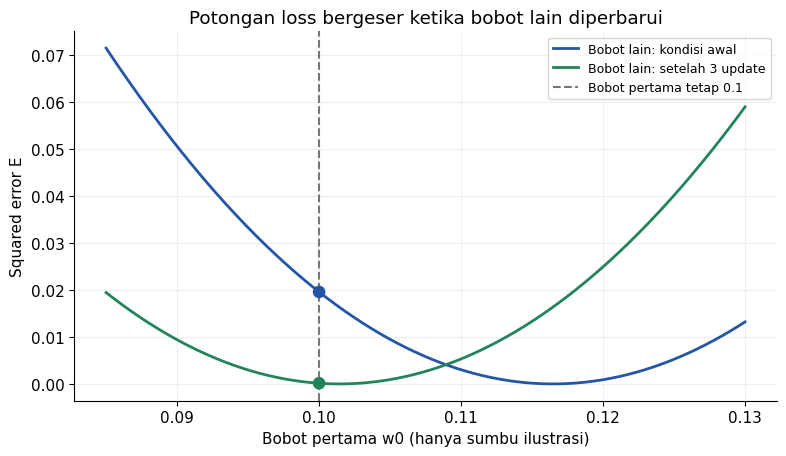

In [7]:
# Visualisasi tambahan: bobot pertama tetap, bobot lain menggeser minimum potongan.
x_vector = np.array(initial_multi_input)
w_initial = np.array(initial_multi_weights)
w_after = np.array(frozen_three_final)
w0_grid = np.linspace(0.085, 0.13, 300)
other_initial = x_vector[1:] @ w_initial[1:]
other_after = x_vector[1:] @ w_after[1:]
loss_initial_slice = (x_vector[0] * w0_grid + other_initial - 1) ** 2
loss_after_slice = (x_vector[0] * w0_grid + other_after - 1) ** 2
loss_at_fixed_initial = (x_vector @ w_initial - 1) ** 2
loss_at_fixed_after = (x_vector @ w_after - 1) ** 2

fig, ax = plt.subplots(figsize=(8.0, 4.7))
ax.plot(w0_grid, loss_initial_slice, color='#2456a6', linewidth=2,
        label='Bobot lain: kondisi awal')
ax.plot(w0_grid, loss_after_slice, color='#21845b', linewidth=2,
        label='Bobot lain: setelah 3 update')
ax.axvline(0.1, color='#777777', linestyle='--', label='Bobot pertama tetap 0.1')
ax.scatter([0.1, 0.1], [loss_at_fixed_initial, loss_at_fixed_after],
           color=['#2456a6', '#21845b'], s=65, zorder=4)
ax.set(title='Potongan loss bergeser ketika bobot lain diperbarui',
       xlabel='Bobot pertama w0 (hanya sumbu ilustrasi)', ylabel='Squared error E')
ax.grid(alpha=0.2)
ax.legend(fontsize=9)
fig.tight_layout()
plt.show()

## 11. Pendalaman: stabilitas, pembekuan, dan solusi yang tidak unik

Bagian ini adalah **derivasi tambahan** untuk model linear satu observasi. Mulai dari update vektor $\mathbf{w}_{t+1}=\mathbf{w}_t-\alpha\delta_t\mathbf{x}$:

$$
\begin{aligned}
\delta_{t+1}
&=\mathbf{x}^{T}\mathbf{w}_{t+1}-y\\
&=\delta_t-\alpha\delta_t\mathbf{x}^{T}\mathbf{x}\\
&=(1-\alpha\|\mathbf{x}\|^2)\delta_t.
\end{aligned}
$$

Untuk input bukan vektor nol, residual dari kondisi awal yang belum tepat menyusut jika:

$$0<\alpha\|\mathbf{x}\|^2<2$$

Dengan bobot pertama dibekukan, kuadrat norma hanya menjumlahkan input pada bobot **aktif**. Pada contoh buku, nilainya $0.65^2+1.2^2=1.8625$. Alpha `0.3` memberi faktor residual `0.44125`, sehingga stabil. Jika semua bobot aktif dengan alpha yang sama, faktor menjadi `-21.23375` dan proses divergen.

### Satu sampel tidak menentukan tiga bobot secara unik

Error nol hanya mensyaratkan $8.5w_0+0.65w_1+1.2w_2=1$. Satu persamaan tersebut mempunyai banyak solusi. Update yang selalu searah $\mathbf{x}$ tidak mengubah komponen bobot yang tegak lurus terhadap $\mathbf{x}$.

Untuk semua bobot aktif dan alpha stabil, batas bobot dari kondisi awal $\mathbf{w}_{\mathrm{awal}}$ adalah:

$$\mathbf{w}_{\infty}=\mathbf{w}_{\mathrm{awal}}
-\frac{\mathbf{x}^{T}\mathbf{w}_{\mathrm{awal}}-y}{\|\mathbf{x}\|^2}\mathbf{x}$$

Pada loss $J$, Hessian adalah $\mathbf{x}\mathbf{x}^{T}$ dan mempunyai rank satu untuk input bukan nol. Loss convex, tetapi datar pada arah yang tidak mengubah prediksi satu observasi. Karena itu, konvergensi residual tidak sama dengan menemukan satu bobot yang secara unik paling benar.

Jika seluruh input aktif bernilai nol dan kontribusi bobot beku belum mencapai target, residual tidak dapat diturunkan melalui bobot aktif. Rumus stabilitas ini juga tidak langsung berlaku pada banyak sampel atau jaringan nonlinear.

In [8]:
# Pemeriksaan tambahan: residual numerik dibandingkan faktor analitis.
frozen_trace = train_one_observation(
    initial_multi_input, 1, initial_multi_weights, 0.3, 12, mask=[0, 1, 1])
x_vector = np.array(initial_multi_input)
initial_residual = x_vector @ np.array(initial_multi_weights) - 1

for name, trace, alpha_value, mask in [
    ('Semua aktif, alpha 0.01', stable_trace, 0.01, np.ones(3)),
    ('Semua aktif, alpha 0.1', unstable_trace, 0.1, np.ones(3)),
    ('Bobot pertama beku, alpha 0.3', frozen_trace, 0.3, np.array([0, 1, 1])),
]:
    active_norm_squared = np.sum(mask * x_vector ** 2)
    factor = 1 - alpha_value * active_norm_squared
    expected = initial_residual * factor ** np.arange(13)
    actual = np.array([row['delta'] for row in trace])
    np.testing.assert_allclose(actual, expected, rtol=1e-7, atol=1e-12)
    print(f'{name}: norma aktif kuadrat={active_norm_squared:.6f}, faktor={factor:.6f}: LULUS')

np.testing.assert_allclose(stable_trace[3]['weights'], multi_three_final)
np.testing.assert_allclose(frozen_trace[3]['weights'], frozen_three_final)
np.testing.assert_allclose([row['weights'][0] for row in frozen_trace], 0.1)
print('Bobot pertama tetap 0.1 di seluruh trajectory pembekuan.')

Semua aktif, alpha 0.01: norma aktif kuadrat=74.112500, faktor=0.258875: LULUS
Semua aktif, alpha 0.1: norma aktif kuadrat=74.112500, faktor=-6.411250: LULUS
Bobot pertama beku, alpha 0.3: norma aktif kuadrat=1.862500, faktor=0.441250: LULUS
Bobot pertama tetap 0.1 di seluruh trajectory pembekuan.


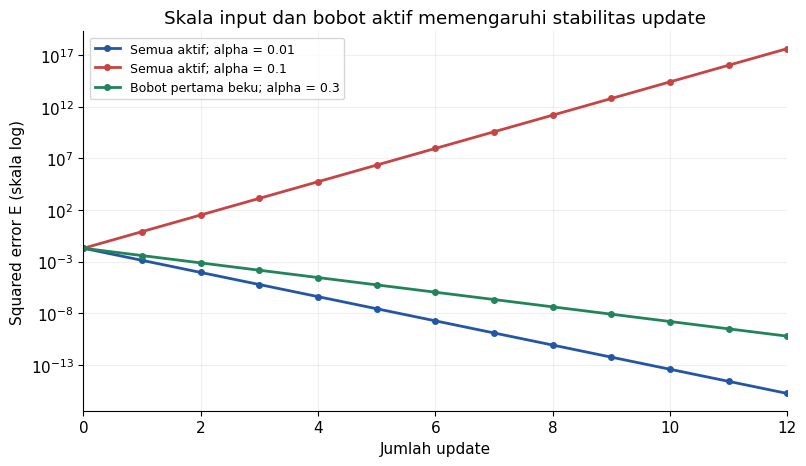

In [9]:
# Visualisasi tambahan: tiga kondisi dengan jumlah update yang sama.
fig, ax = plt.subplots(figsize=(8.2, 4.8))
for trace, label, color in [
    (stable_trace, 'Semua aktif; alpha = 0.01', '#2456a6'),
    (unstable_trace, 'Semua aktif; alpha = 0.1', '#c74444'),
    (frozen_trace, 'Bobot pertama beku; alpha = 0.3', '#21845b'),
]:
    ax.semilogy([row['step'] for row in trace], [row['error'] for row in trace],
                color=color, marker='o', markersize=4, linewidth=2, label=label)
ax.set(title='Skala input dan bobot aktif memengaruhi stabilitas update',
       xlabel='Jumlah update', ylabel='Squared error E (skala log)', xlim=(0, 12))
ax.set_xticks(np.arange(0, 13, 2))
ax.grid(alpha=0.2)
ax.legend(fontsize=9)
fig.tight_layout()
plt.show()

### Dua bobot berbeda dapat cocok pada satu observasi

Kode tambahan berikut membuat satu solusi yang memprediksi pertandingan pertama dengan tepat, kemudian menambahkan vektor yang tegak lurus terhadap input pertama. Prediksi pertandingan pertama tetap sama, tetapi prediksi untuk observasi lain dapat berbeda.

Hal ini menjelaskan keterbatasan belajar dari satu sampel. Jika residual training sudah nol, gradien dari sampel itu juga nol; feature yang mungkin berguna pada sampel lain tidak mendapat update tambahan dari sampel pertama tersebut.

**Rujukan konsep:** Trask (2019), hlm. 89. Konstruksi solusi numerik berikut adalah tambahan.

In [10]:
# Ilustrasi tambahan: solusi loss nol tidak unik untuk satu observasi.
x_first = np.array(initial_multi_input)
w_solution_a = x_first / (x_first @ x_first)  # Target pertama adalah 1.
orthogonal_change = np.array([0.65, -8.5, 0.0])
w_solution_b = w_solution_a + 0.1 * orthogonal_change
x_second = np.array([9.5, 0.8, 1.3])

print('Solusi A:', w_solution_a)
print('Solusi B:', w_solution_b)
print('Prediksi observasi pertama, A / B:', x_first @ w_solution_a, '/', x_first @ w_solution_b)
print('Prediksi observasi kedua, A / B:', x_second @ w_solution_a, '/', x_second @ w_solution_b)
np.testing.assert_allclose(x_first @ orthogonal_change, 0, atol=1e-12)
np.testing.assert_allclose([x_first @ w_solution_a, x_first @ w_solution_b], [1, 1])

Solusi A: [0.1146905  0.00877045 0.0161916 ]
Solusi B: [ 0.1796905  -0.84122955  0.0161916 ]
Prediksi observasi pertama, A / B: 1.0 / 1.0
Prediksi observasi kedua, A / B: 1.117625231910946 / 1.055125231910946


## 12. Gradient descent learning with multiple outputs

Untuk satu input $x$ dan beberapa output, setiap output mempunyai bobot dan target tersendiri:

$$\hat{y}_j=xw_j,\quad\delta_j=\hat{y}_j-y_j,
\quad\frac{\partial J}{\partial w_j}=x\delta_j$$

Sekarang residualnya berbeda antar output, sedangkan inputnya sama. Dengan $J=\tfrac12\sum_j\delta_j^2$, aturan update tetap mengurangkan alpha dikali gradien. Buku menyimpan squared error setiap output dalam list, bukan langsung merata-ratakannya.

**Asal kode:** reproduksi gabungan hlm. 90-91. Bobot `[0.3, 0.2, 0.9]`, input `0.65`, serta target `[0.1, 1, 0.1]` mewakili keluaran `hurt`, `win`, dan `sad`.

Prediksi awal adalah `[0.195, 0.13, 0.585]`, residual `[0.095, -0.87, 0.485]`, dan gradien `[0.06175, -0.5655, 0.31525]`. Dengan alpha `0.1`, bobot baru menjadi `[0.293825, 0.25655, 0.868475]`.

**Koreksi penting hlm. 91:** `scalar_ele_mul(input, weights)` diganti menjadi `scalar_ele_mul(input_data, delta)`. Penjelasan bab dan diagram gradien memakai input dikali **residual**, bukan input dikali bobot. Mengalikan input dan bobot hanya menghitung kembali prediksi, sehingga tidak memberikan gradien yang dibutuhkan.

In [11]:
# Reproduksi gabungan hlm. 90-91; argumen gradien dikoreksi menjadi delta.
def scalar_ele_mul(number, vector):
    output = [0, 0, 0]
    assert len(output) == len(vector)
    for i in range(len(vector)):
        output[i] = number * vector[i]
    return output

weights = [0.3, 0.2, 0.9]

def neural_network(input_data, weights):
    pred = scalar_ele_mul(input_data, weights)
    return pred

wlrec = [0.65, 1.0, 1.0, 0.9]
hurt = [0.1, 0.0, 0.0, 0.1]
win = [1, 1, 0, 1]
sad = [0.1, 0.0, 0.1, 0.2]
input_data = wlrec[0]
true = [hurt[0], win[0], sad[0]]
pred = neural_network(input_data, weights)
error = [0, 0, 0]
delta = [0, 0, 0]
for i in range(len(true)):
    error[i] = (pred[i] - true[i]) ** 2
    delta[i] = pred[i] - true[i]

weight_deltas = scalar_ele_mul(input_data, delta)
alpha = 0.1
multi_output_step = {
    'initial_weights': weights.copy(), 'prediction': pred.copy(),
    'error': error.copy(), 'delta': delta.copy(), 'gradient': weight_deltas.copy(),
}
for i in range(len(weights)):
    weights[i] -= weight_deltas[i] * alpha

multi_output_step['new_weights'] = weights.copy()
multi_output_step['new_prediction'] = neural_network(input_data, weights)
print('Prediction awal:', pred)
print('Error per output:', error)
print('Jumlah squared error:', sum(error))
print('Delta per output:', delta)
print('Weights:' + str(weights))
print('Weight Deltas:' + str(weight_deltas))
print('Prediction sesudah update:', multi_output_step['new_prediction'])

Prediction awal: [0.195, 0.13, 0.5850000000000001]
Error per output: [0.009025, 0.7569, 0.2352250000000001]
Jumlah squared error: 1.0011500000000002
Delta per output: [0.095, -0.87, 0.4850000000000001]
Weights:[0.293825, 0.25655, 0.868475]
Weight Deltas:[0.061750000000000006, -0.5655, 0.3152500000000001]
Prediction sesudah update: [0.19098625, 0.1667575, 0.56450875]


## 13. Satu input banyak output dibandingkan banyak input satu output

| Arsitektur | Prediksi | Residual | Gradien bobot |
| --- | --- | --- | --- |
| Banyak input, satu output | $\hat{y}=\sum_i x_iw_i$ | Satu $\delta$ bersama | $g_i=x_i\delta$ |
| Satu input, banyak output | $\hat{y}_j=xw_j$ | Satu $\delta_j$ untuk setiap output | $g_j=x\delta_j$ |
| Banyak input, banyak output | $\hat{y}_j=\sum_i W_{ji}x_i$ | Satu $\delta_j$ untuk setiap output | $G_{ji}=\delta_jx_i$ |

Untuk $m$ output, notebook membedakan **jumlah squared error** $\sum_j\delta_j^2$ dari **MSE antar output** $\frac1m\sum_j\delta_j^2$. Kode buku memakai gradien half **sum** squared error, bukan gradien MSE penuh. Rata-rata akan mengubah skala gradien dan perlu diperhitungkan dalam alpha.

Model pada bab ini masih satu lapisan linear, tanpa bias atau softmax. Nama keluaran seperti `win` dan `sad` tidak otomatis membuat skornya probabilitas. Bagian MNIST memakai istilah skor kelas untuk keluaran linear ini.

**Rujukan:** Trask (2019), hlm. 80-85 dan 90-93.

## 14. Matriks bobot dan orientasi outer product

Dalam listing hlm. 92, setiap **baris** matriks bobot menuju satu output, sedangkan setiap **kolom** berkaitan dengan satu input. Dengan $n$ input dan $m$ output:

$$
W\in\mathbb{R}^{m\times n},\quad
\hat{\mathbf{y}}=W\mathbf{x},\quad
\boldsymbol{\delta}=\hat{\mathbf{y}}-\mathbf{y}
$$

Untuk $J=\tfrac12\sum_j\delta_j^2$, setiap elemen gradien adalah:

$$\frac{\partial J}{\partial W_{ji}}=\delta_jx_i,
\qquad G=\boldsymbol{\delta}\mathbf{x}^{T}$$

**Outer product** mengalikan setiap elemen vektor pertama dengan setiap elemen vektor kedua, menghasilkan matriks. Dengan orientasi bobot buku, pemanggilan yang sesuai adalah `outer_prod(delta, input_data)` atau `np.outer(delta, input_data)`. Bentuk hasilnya harus sama dengan bentuk `weights`.

| Besaran | Shape | Orientasi |
| --- | --- | --- |
| Input $\mathbf{x}$ | $(n,)$ pada NumPy | Satu nilai per feature |
| Bobot $W$ | $(m,n)$ | Baris output, kolom input |
| Prediksi dan residual | $(m,)$ | Satu nilai per output |
| Gradien $G$ | $(m,n)$ | Sama dengan matriks bobot |

Jika bobot disimpan dengan orientasi yang ditranspose, rumus outer product juga harus ditranspose. Dimensi `3 × 3` dapat menyembunyikan kekeliruan orientasi karena shape tetap cocok. Karena itu, bagian 17 memeriksa contoh `2 × 3` juga.

**Rujukan:** Trask (2019), hlm. 92-93; definisi outer product diperiksa dengan [dokumentasi resmi NumPy](https://numpy.org/doc/stable/reference/generated/numpy.outer.html).

### Koreksi listing pada halaman 92-93

| Bagian buku | Penyesuaian | Alasan |
| --- | --- | --- |
| `delta = pred[i] - true[i]` | `delta[i] = pred[i] - true[i]` | Menyimpan residual setiap output, bukan mengganti list dengan scalar |
| `len(a)` / `len(b)` dalam `outer_prod(vec_a, vec_b)` | `len(vec_a)` / `len(vec_b)` | Memakai nama argumen fungsi yang benar |
| Pemanggilan `zeros_matrix(...)` tanpa definisi pada bagian tersebut | Tambahkan helper pembuat matriks nol | Melengkapi kode agar mandiri dan dapat dijalankan |
| `outer_prod(input, delta)` | `outer_prod(delta, input_data)` | Menyesuaikan gradien dengan baris bobot yang mewakili output |
| Error output `win` diberi label sekitar `0.96` pada diagram hlm. 92 | Nilai kode: $(0.98-1)^2=0.0004$ | Squared error berbeda dari nilai prediksi |

Koreksi dilakukan terbuka; angka input, target, bobot awal, dan alpha buku dipertahankan. Helper `vect_mat_mul` tiga input/tiga output berikut mengikuti struktur square contoh buku. Versi untuk bentuk umum diberikan terpisah.

## 15. Gradient descent dengan banyak input dan output

**Asal kode:** reproduksi gabungan hlm. 92-93 dengan koreksi di atas. Urutan output adalah `hurt`, `win`, `sad`; urutan input adalah `toes`, `wlrec`, `nfans`.

Dengan input `[8.5, 0.65, 1.2]`, prediksi awal `[0.555, 0.98, 0.965]` dan target `[0.1, 1, 0.1]`. Residual `[0.455, -0.02, 0.865]` dikalikan seluruh input untuk menghasilkan setiap baris gradien. Satu langkah memperbarui sembilan bobot.

Contoh ini memperbesar lapisan linear, bukan menambahkan hidden layer. Pembelajaran jaringan dalam memerlukan propagasi error ke lapisan sebelumnya, yang menjadi pembahasan Chapter 6.

In [12]:
# Reproduksi gabungan hlm. 92-93 dengan koreksi nama, indeks, dan orientasi.
def vect_mat_mul(vect, matrix):
    assert len(vect) == len(matrix)  # Sesuai contoh square 3 x 3 buku.
    output = [0, 0, 0]
    for i in range(len(vect)):
        output[i] = w_sum(vect, matrix[i])
    return output

# Helper pendamping untuk fungsi yang dirujuk tetapi tidak didefinisikan pada hlm. 93.
def zeros_matrix(rows, columns):
    return [[0 for j in range(columns)] for i in range(rows)]

def outer_prod(vec_a, vec_b):
    out = zeros_matrix(len(vec_a), len(vec_b))
    for i in range(len(vec_a)):
        for j in range(len(vec_b)):
            out[i][j] = vec_a[i] * vec_b[j]
    return out

weights = [
    [0.1, 0.1, -0.3],  # hurt
    [0.1, 0.2, 0.0],   # win
    [0.0, 1.3, 0.1],   # sad
]

def neural_network(input_data, weights):
    pred = vect_mat_mul(input_data, weights)
    return pred

toes = [8.5, 9.5, 9.9, 9.0]
wlrec = [0.65, 0.8, 0.8, 0.9]
nfans = [1.2, 1.3, 0.5, 1.0]
hurt = [0.1, 0.0, 0.0, 0.1]
win = [1, 1, 0, 1]
sad = [0.1, 0.0, 0.1, 0.2]
alpha = 0.01
input_data = [toes[0], wlrec[0], nfans[0]]
true = [hurt[0], win[0], sad[0]]
pred = neural_network(input_data, weights)
error = [0, 0, 0]
delta = [0, 0, 0]
for i in range(len(true)):
    error[i] = (pred[i] - true[i]) ** 2
    delta[i] = pred[i] - true[i]

weight_deltas = outer_prod(delta, input_data)
matrix_step = {
    'initial_weights': [row.copy() for row in weights],
    'input': input_data.copy(), 'target': true.copy(),
    'prediction': pred.copy(), 'error': error.copy(), 'delta': delta.copy(),
    'gradient': [row.copy() for row in weight_deltas],
}
for i in range(len(weights)):
    for j in range(len(weights[0])):
        weights[i][j] -= alpha * weight_deltas[i][j]

matrix_step['new_weights'] = [row.copy() for row in weights]
matrix_step['new_prediction'] = neural_network(input_data, weights)
print('Prediction sebelum update:', pred)
print('Squared error per output:', error)
print('Delta:', delta)
print('Matriks gradien, baris = output:')
for row in weight_deltas:
    print(row)
print('Matriks bobot baru:')
for row in weights:
    print(row)
print('Prediction sesudah update:', matrix_step['new_prediction'])
print('Jumlah squared error sebelum update:', sum(error))
print('Jumlah squared error sesudah update:',
      sum((p - t) ** 2 for p, t in zip(matrix_step['new_prediction'], true)))

Prediction sebelum update: [0.555, 0.9800000000000001, 0.9650000000000001]
Squared error per output: [0.20702500000000007, 0.0003999999999999963, 0.7482250000000001]
Delta: [0.45500000000000007, -0.019999999999999907, 0.8650000000000001]
Matriks gradien, baris = output:
[3.8675000000000006, 0.29575000000000007, 0.546]
[-0.1699999999999992, -0.01299999999999994, -0.023999999999999886]
[7.352500000000001, 0.5622500000000001, 1.038]
Matriks bobot baru:
[0.061325, 0.0970425, -0.30546]
[0.1017, 0.20013, 0.00023999999999999887]
[-0.07352500000000001, 1.2943775, 0.08962]
Prediction sesudah update: [0.217788125, 0.9948224999999999, 0.32392687499999984]
Jumlah squared error sebelum update: 0.9556500000000002
Jumlah squared error sesudah update: 0.06404409424453118


## 16. Versi NumPy dan pemeriksaan turunan

**Asal kode berikut:** implementasi tambahan yang setara dengan reproduksi matriks, bukan listing NumPy dari bab. Operasi `W @ x` menghasilkan prediksi dan `np.outer(delta, x)` menghasilkan gradien. Sel ini membandingkan hasil NumPy dengan versi list.

Pemeriksaan berikutnya menggunakan **central finite difference** untuk mendekati turunan $J$ terhadap setiap elemen bobot. Mengubah satu elemen bobot sedikit ke dua arah memberikan pemeriksaan independen atas rumus gradien, termasuk orientasinya. Loss yang diperiksa adalah half sum squared error agar sesuai dengan update buku.

In [13]:
# Implementasi NumPy tambahan yang setara dengan contoh list.
W_before = np.array(matrix_step['initial_weights'], dtype=float)
x_vector = np.array(matrix_step['input'], dtype=float)
target_vector = np.array(matrix_step['target'], dtype=float)
prediction_np = W_before @ x_vector
delta_np = prediction_np - target_vector
gradient_np = np.outer(delta_np, x_vector)
W_after_np = W_before - 0.01 * gradient_np

print('Shape W, input, prediction, gradient:',
      W_before.shape, x_vector.shape, prediction_np.shape, gradient_np.shape)
print('Prediction NumPy:', prediction_np)
print('Gradien NumPy:')
print(gradient_np)
np.testing.assert_allclose(prediction_np, matrix_step['prediction'])
np.testing.assert_allclose(gradient_np, matrix_step['gradient'])
np.testing.assert_allclose(W_after_np, matrix_step['new_weights'])
print('Kesetaraan list dan NumPy: LULUS')

Shape W, input, prediction, gradient: (3, 3) (3,) (3,) (3, 3)
Prediction NumPy: [0.555 0.98  0.965]
Gradien NumPy:
[[ 3.8675   0.29575  0.546  ]
 [-0.17    -0.013   -0.024  ]
 [ 7.3525   0.56225  1.038  ]]
Kesetaraan list dan NumPy: LULUS


In [14]:
# Pemeriksaan gradien tambahan untuk seluruh sembilan bobot.
def half_sum_squared_loss(weight_matrix, x_vector, target_vector):
    residual = weight_matrix @ x_vector - target_vector
    return 0.5 * np.sum(residual ** 2)

epsilon_fd = 1e-6
finite_difference_matrix = np.zeros_like(W_before)
for output_index in range(W_before.shape[0]):
    for input_index in range(W_before.shape[1]):
        W_plus = W_before.copy()
        W_minus = W_before.copy()
        W_plus[output_index, input_index] += epsilon_fd
        W_minus[output_index, input_index] -= epsilon_fd
        finite_difference_matrix[output_index, input_index] = (
            half_sum_squared_loss(W_plus, x_vector, target_vector)
            - half_sum_squared_loss(W_minus, x_vector, target_vector)
        ) / (2 * epsilon_fd)

print('Pendekatan finite difference:')
print(finite_difference_matrix)
print('Selisih absolut terbesar:', np.max(np.abs(finite_difference_matrix - gradient_np)))
np.testing.assert_allclose(finite_difference_matrix, gradient_np, rtol=1e-7, atol=1e-8)
print('Pemeriksaan turunan semua elemen: LULUS')

Pendekatan finite difference:
[[ 3.8675   0.29575  0.546  ]
 [-0.17    -0.013   -0.024  ]
 [ 7.3525   0.56225  1.038  ]]
Selisih absolut terbesar: 5.3082427342587835e-11
Pemeriksaan turunan semua elemen: LULUS


## 17. Bentuk matriks tidak harus square

**Asal kode:** generalisasi tambahan dari helper hlm. 92. Pada bentuk umum, jumlah input harus sesuai dengan panjang setiap baris bobot; jumlah output sesuai dengan jumlah baris bobot. Syarat `len(vect) == len(matrix)` pada contoh square buku belum memeriksa hubungan tersebut secara umum.

Contoh dua output dan tiga input di bawah menghasilkan bobot dan gradien berukuran `2 × 3`. Outer product dalam urutan terbalik menghasilkan `3 × 2`, sehingga kesalahan orientasi terlihat. Dengan bentuk square, kesalahan yang sama dapat lolos pemeriksaan shape namun menghasilkan update yang keliru.

In [15]:
# Generalisasi tambahan: dua output, tiga input.
def vect_mat_mul_general(vect, matrix):
    assert all(len(row) == len(vect) for row in matrix)
    return [w_sum(vect, row) for row in matrix]

rectangular_weights = [[0.1, 0.2, -0.1], [0.2, -0.3, 0.4]]
rectangular_input = [8.5, 0.65, 1.2]
rectangular_target = np.array([1.0, 0.1])
rectangular_pred = np.array(vect_mat_mul_general(rectangular_input, rectangular_weights))
rectangular_delta = rectangular_pred - rectangular_target
rectangular_gradient = np.array(outer_prod(rectangular_delta, rectangular_input))
reverse_outer = np.outer(rectangular_input, rectangular_delta)

print('Prediction:', rectangular_pred)
print('Shape bobot:', np.array(rectangular_weights).shape)
print('Shape gradien yang sesuai:', rectangular_gradient.shape)
print('Shape outer product urutan terbalik:', reverse_outer.shape)
assert rectangular_gradient.shape == np.array(rectangular_weights).shape == (2, 3)
np.testing.assert_allclose(rectangular_gradient, np.outer(rectangular_delta, rectangular_input))
np.testing.assert_allclose(rectangular_pred, np.array(rectangular_weights) @ rectangular_input)
print('Generalisasi bentuk 2 x 3: LULUS')

Prediction: [0.86  1.985]
Shape bobot: (2, 3)
Shape gradien yang sesuai: (2, 3)
Shape outer product urutan terbalik: (3, 2)
Generalisasi bentuk 2 x 3: LULUS


## 18. What do these weights learn? Pengantar MNIST

MNIST berisi gambar grayscale digit tulisan tangan `0` sampai `9`. Gambar berukuran `28 × 28` mempunyai `784` pixel. Dalam model linear yang diperkenalkan buku, setiap pixel menjadi satu input dan setiap digit mempunyai satu output, sehingga matriks bobot berukuran `10 × 784` menurut orientasi baris-output yang digunakan notebook.

**Flattening** menyusun pixel gambar menjadi vektor tanpa mengubah nilainya. Dengan urutan per baris, pixel baris $r$, kolom $c$ menjadi elemen $28r+c$ untuk indeks yang dimulai dari nol. Reshape dengan urutan yang sama dapat mengembalikan bentuk gambar; geometri spasial tetap ada dalam urutan data, tetapi model linear memperlakukan setiap posisi sebagai feature tersendiri.

**One-hot target** memakai sepuluh elemen: target digit `2` adalah `[0, 0, 1, 0, 0, 0, 0, 0, 0, 0]`. Indeks `0` mewakili digit `0`, sehingga digit `2` berada pada elemen ketiga. Skor tertinggi dapat dipilih dengan `argmax`.

| Besaran | Bentuk |
| --- | --- |
| Satu gambar mentah | $(28,28)$ |
| Satu gambar setelah flatten | $(784,)$ |
| $N$ gambar setelah flatten | $(N,784)$ |
| Target one-hot | $(N,10)$ |
| Bobot satu lapisan, tanpa bias | $(10,784)$; 7.840 parameter |
| Skor seluruh gambar | $(N,10)$, dari `images @ weights.T` |

Buku mengacu pada `MNISTPreprocessor.ipynb` untuk menyiapkan subset pertama 1.000 gambar. File pendamping tersebut tersedia di [repository penulis](https://github.com/iamtrask/Grokking-Deep-Learning/blob/master/MNISTPreprocessor.ipynb). Halaman 94-97 tidak memberikan listing pelatihan MNIST lengkap.

Sebagai konteks tambahan, [dokumentasi resmi Keras tentang MNIST](https://keras.io/api/datasets/mnist/) mencatat 60.000 gambar training dan 10.000 gambar test, dengan pixel mentah `0-255`. Ilustrasi berikut memakai **dua pola sintetis**, bukan subset data MNIST. Tujuannya menunjukkan flattening, one-hot, dan bentuk operasi tanpa unduhan.

**Rujukan:** Trask (2019), hlm. 94-95; Keras untuk bentuk dataset lengkap dan rentang pixel.

In [16]:
# Ilustrasi tambahan: dua pola sederhana 28 x 28, bukan data MNIST.
synthetic_one = np.zeros((28, 28), dtype=np.uint8)
synthetic_one[4:24, 13:16] = 255
synthetic_one[4:7, 10:13] = 255
synthetic_one[21:24, 9:20] = 255

synthetic_two = np.zeros((28, 28), dtype=np.uint8)
synthetic_two[4:7, 6:22] = 255
synthetic_two[7:13, 19:22] = 255
synthetic_two[12:15, 6:22] = 255
synthetic_two[15:21, 6:9] = 255
synthetic_two[21:24, 6:22] = 255

synthetic_images_raw = np.stack([synthetic_one, synthetic_two])
synthetic_labels = np.array([1, 2])
image_vectors = synthetic_images_raw.astype(float).reshape(2, 784) / 255.0
one_hot_targets = np.eye(10)[synthetic_labels]
digit_weights = np.zeros((10, 784))

print('Shape gambar mentah:', synthetic_images_raw.shape)
print('Shape setelah flatten:', image_vectors.shape)
print('Shape target one-hot:', one_hot_targets.shape)
print('One-hot untuk digit 2:', one_hot_targets[1])
print('Shape bobot:', digit_weights.shape)
print('Jumlah bobot:', digit_weights.size)
print('Shape skor:', (image_vectors @ digit_weights.T).shape)
np.testing.assert_array_equal(
    image_vectors[1].reshape(28, 28), synthetic_images_raw[1].astype(float) / 255.0)
print('Flatten dan reshape mempertahankan urutan pixel: LULUS')

Shape gambar mentah: (2, 28, 28)
Shape setelah flatten: (2, 784)
Shape target one-hot: (2, 10)
One-hot untuk digit 2: [0. 0. 1. 0. 0. 0. 0. 0. 0. 0.]
Shape bobot: (10, 784)
Jumlah bobot: 7840
Shape skor: (2, 10)
Flatten dan reshape mempertahankan urutan pixel: LULUS


## 19. Visualizing weight values

Setiap kelas mempunyai satu baris dengan 784 bobot. Mengubah baris itu menjadi `28 × 28` membuat peta kontribusi posisi pixel terhadap skor kelas:

$$s_j=\sum_{i=1}^{784}W_{ji}x_i$$

Dengan pixel nonnegatif, bobot positif meningkatkan skor ketika pixel tersebut aktif; bobot negatif menurunkan skor. Warna di sekitar nol menunjukkan pengaruh yang kecil pada model linear. Pada model ini, pengaruh tambahan satu pixel terhadap skor kelas $j$ adalah bobot $W_{ji}$.

Buku menghubungkan peta bobot dengan pola digit yang dipelajari. Secara lebih tepat, bobot adalah parameter yang dioptimalkan dari loss, bukan nilai koefisien korelasi Pearson. Bobot juga tidak membuktikan hubungan kausal antara pixel dan kelas. Informasinya dibaca bersama input, preprocessing, dan arsitektur model.

**Eksperimen tambahan berikut:** model `10 × 784` dilatih hanya pada dua pola sintetis dari bagian 18. Ini membuat peta bobot berasal dari update gradien yang benar-benar dijalankan, bukan peta yang digambar manual. Bobot awal nol cukup untuk model linear ini. Alpha dipilih berdasarkan kuadrat norma input, dan pelatihan memakai outer product residual dan input.

Seluruh contoh hanya mencocokkan dua pola training; hasilnya tidak mengukur kemampuan membaca tulisan tangan atau akurasi MNIST. Kelas lain tidak diberikan contoh positif. Eksperimen ini mendampingi visualisasi konseptual hlm. 96-97.

**Rujukan:** Trask (2019), hlm. 96-97; implementasi pelatihan sintetis adalah tambahan.

In [17]:
# Eksperimen tambahan: training pada dua pola sintetis, bukan pelatihan MNIST.
digit_weights = np.zeros((10, 784))
synthetic_alpha = 0.8 / np.max(np.sum(image_vectors ** 2, axis=1))

def mean_total_squared_error(weight_matrix):
    scores = image_vectors @ weight_matrix.T
    return np.mean(np.sum((scores - one_hot_targets) ** 2, axis=1))

synthetic_loss_history = [(0, mean_total_squared_error(digit_weights))]
print('Alpha ilustrasi:', synthetic_alpha)
print('Rata-rata jumlah squared error awal:', synthetic_loss_history[0][1])
for epoch in range(1, 81):
    for image, target in zip(image_vectors, one_hot_targets):
        scores = digit_weights @ image
        residual = scores - target
        gradient = np.outer(residual, image)
        digit_weights -= synthetic_alpha * gradient
    current_loss = mean_total_squared_error(digit_weights)
    synthetic_loss_history.append((epoch, current_loss))
    if epoch in [1, 10, 40, 80]:
        print(f'Epoch {epoch:2d} | Rata-rata jumlah squared error: {current_loss:.8e}')

synthetic_scores = image_vectors @ digit_weights.T
print('Skor untuk dua pola training:')
print(synthetic_scores)
print('Argmax pada pola 1 dan 2:', np.argmax(synthetic_scores, axis=1))
print('Angka di atas hanya hasil dua pola sintetis training.')

Alpha ilustrasi: 0.004519774011299435
Rata-rata jumlah squared error awal: 1.0
Epoch  1 | Rata-rata jumlah squared error: 2.71579031e-01
Epoch 10 | Rata-rata jumlah squared error: 2.92694162e-04
Epoch 40 | Rata-rata jumlah squared error: 3.59059223e-14
Epoch 80 | Rata-rata jumlah squared error: 2.18137075e-27
Skor untuk dua pola training:
[[0. 1. 0. 0. 0. 0. 0. 0. 0. 0.]
 [0. 0. 1. 0. 0. 0. 0. 0. 0. 0.]]
Argmax pada pola 1 dan 2: [1 2]
Angka di atas hanya hasil dua pola sintetis training.


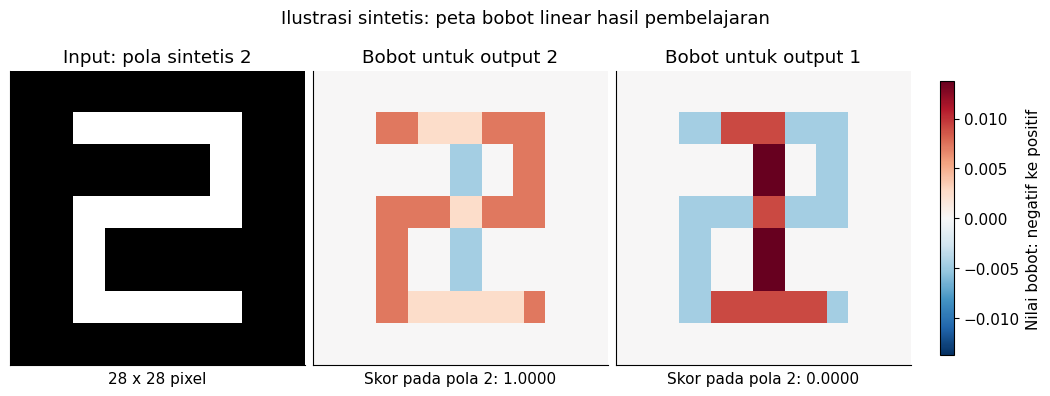

In [18]:
# Visualisasi tambahan: input sintetis dan peta bobot hasil training sintetis.
weight_map_two = digit_weights[2].reshape(28, 28)
weight_map_one = digit_weights[1].reshape(28, 28)
color_limit = max(np.max(np.abs(weight_map_two)), np.max(np.abs(weight_map_one)))

fig, axes = plt.subplots(1, 3, figsize=(10.4, 4.0), layout='constrained')
axes[0].imshow(image_vectors[1].reshape(28, 28), cmap='gray', vmin=0, vmax=1,
               interpolation='nearest')
axes[0].set_title('Input: pola sintetis 2')
axes[0].set_xlabel('28 x 28 pixel')
for ax, weight_map, digit in [(axes[1], weight_map_two, 2), (axes[2], weight_map_one, 1)]:
    im = ax.imshow(weight_map, cmap='RdBu_r', vmin=-color_limit, vmax=color_limit,
                   interpolation='nearest')
    ax.set_title(f'Bobot untuk output {digit}')
    ax.set_xlabel(f'Skor pada pola 2: {synthetic_scores[1, digit]:.4f}')
for ax in axes:
    ax.set_xticks([])
    ax.set_yticks([])
fig.colorbar(im, ax=axes[1:], shrink=0.75, label='Nilai bobot: negatif ke positif')
fig.suptitle('Ilustrasi sintetis: peta bobot linear hasil pembelajaran', fontsize=13)
plt.show()

## 20. Visualizing dot products: weighted sums

**Asal kode:** nilai vektor `a`, `b`, `c`, dan `d` direproduksi dari hlm. 97. Perhitungan serta pencetakan ditambahkan untuk memperlihatkan perkalian elementwise dan jumlahnya.

Dot product menghitung:

$$\mathbf{a}^{T}\mathbf{b}=\sum_i a_ib_i$$

Pada pola nonnegatif di contoh buku, posisi aktif yang berimpit memberi kontribusi positif. Vektor `a` dan `b` tidak mempunyai posisi aktif yang sama sehingga hasilnya nol. `c` dan `d` mempunyai overlap dan menghasilkan `0.5`, sedangkan `b` dan `c` menghasilkan `1`.

Pada input gambar, output kelas adalah dot product antara vektor pixel dan baris bobot kelas tersebut. Bentuk pixel yang cocok dengan bobot positif meningkatkan skor; pixel yang aktif pada bobot negatif menurunkannya.

**Rujukan:** Trask (2019), hlm. 97.

In [19]:
# Vektor dari hlm. 97; perhitungan eksplisit adalah tambahan.
a = [0, 1, 0, 1]
b = [1, 0, 1, 0]
c = [0, 1, 1, 0]
d = [0.5, 0, 0.5, 0]
dot_results = {}
for name, vector_a, vector_b in [
    ('a dot b', a, b), ('c dot d', c, d), ('b dot c', b, c), ('b dot b', b, b),
]:
    elementwise = [x_value * y_value for x_value, y_value in zip(vector_a, vector_b)]
    score = w_sum(vector_a, vector_b)
    dot_results[name] = score
    print(f'{name}: elementwise = {elementwise}, jumlah = {score}')

pixel_contributions = image_vectors[1] * digit_weights[2]
print('Jumlah kontribusi pixel sintetis ke output 2:', np.sum(pixel_contributions))
print('Skor output 2 dari perkalian matriks:', synthetic_scores[1, 2])
np.testing.assert_allclose(np.sum(pixel_contributions), synthetic_scores[1, 2])

a dot b: elementwise = [0, 0, 0, 0], jumlah = 0
c dot d: elementwise = [0.0, 0, 0.5, 0], jumlah = 0.5
b dot c: elementwise = [0, 0, 1, 0], jumlah = 1
b dot b: elementwise = [1, 0, 1, 0], jumlah = 2
Jumlah kontribusi pixel sintetis ke output 2: 0.9999999999999962
Skor output 2 dari perkalian matriks: 0.9999999999999969


### Dot product bukan ukuran similarity yang dinormalisasi

Buku menyebut dot product sebagai ukuran kemiripan secara longgar. Dot product dipengaruhi arah **dan panjang** vektor:

$$\mathbf{a}^{T}\mathbf{b}=\|\mathbf{a}\|\|\mathbf{b}\|\cos\theta$$

Jika satu vektor diperbesar, dot product membesar walaupun arah pola tetap sama. Untuk dua vektor bukan nol, cosine similarity membagi dot product dengan hasil kali normanya. Cosine similarity digunakan di sini sebagai penjelasan tambahan; model buku tetap memakai weighted sum biasa.

Untuk vektor bertanda, hasil nol juga dapat terjadi karena kontribusi positif dan negatif saling meniadakan, bukan hanya karena posisi aktifnya tidak berimpit. Bobot neural network dapat negatif, sehingga interpretasi overlap harus memperhatikan tanda serta skala.

**Rujukan konsep dot product:** Trask (2019), hlm. 97. Formula norma dan ilustrasi cosine merupakan pendalaman tambahan.

In [20]:
# Pendalaman tambahan: panjang vektor memengaruhi dot product.
b_vector = np.array(b, dtype=float)
b_scaled = 100 * b_vector
for name, other in [('b', b_vector), ('100 * b', b_scaled)]:
    dot = b_vector @ other
    cosine = dot / (np.linalg.norm(b_vector) * np.linalg.norm(other))
    print(f'b dibanding {name}: dot product = {dot:.1f}, cosine similarity = {cosine:.1f}')

b dibanding b: dot product = 2.0, cosine similarity = 1.0
b dibanding 100 * b: dot product = 200.0, cosine similarity = 1.0


## 21. Kesimpulan teori Chapter 5

Gradient descent dapat memperbarui banyak bobot selama pengaruh setiap parameter terhadap loss dapat dihitung. Pada lapisan linear bab ini, gradien setiap koneksi adalah nilai input dikali residual output yang terhubung. Outer product mengemas semua perkalian itu dalam matriks.

Pembekuan bobot memperlihatkan bahwa sebagian parameter dapat dipertahankan sementara parameter lain tetap belajar. Pada satu observasi, error nol dapat dicapai dengan banyak kombinasi bobot, sehingga bobot akhir perlu ditafsirkan berdasarkan data yang digunakan untuk training.

Visualisasi bobot membantu membaca bagaimana pixel memberi kontribusi terhadap skor kelas. Penjelasan dot product memperlihatkan bahwa skor dipengaruhi overlap, tanda, serta besar vektor. Skor linear, koefisien korelasi, dan probabilitas adalah konsep yang berbeda.

Contoh bab ini memperbesar jumlah input dan output dalam satu lapisan. Chapter 6 membahas pembelajaran jaringan dengan hidden layer dan propagasi error melalui backpropagation.

**Rujukan:** Trask (2019), hlm. 98 serta pengantar Chapter 6.

## 22. Verifikasi hasil reproduksi

Pemeriksaan berikut memverifikasi angka inti, kesetaraan versi list/NumPy, pembekuan parameter, serta hasil dot product. Pemeriksaan gradien dengan finite difference dan residual dengan solusi analitis sudah dilakukan pada bagian sebelumnya.

Floating point dapat menampilkan desimal dengan sedikit selisih representasi. Angka inti dibandingkan dengan toleransi yang sesuai. Perilaku divergence pada eksperimen alpha `0.1` merupakan hasil yang sengaja dipelajari, bukan exception Python.

In [21]:
# Pemeriksaan tambahan atas hasil inti bab.
np.testing.assert_allclose(multi_input_step['prediction'], 0.86)
np.testing.assert_allclose(multi_input_step['error'], 0.0196)
np.testing.assert_allclose(multi_input_step['delta'], -0.14)
np.testing.assert_allclose(multi_input_step['gradients'], [-1.19, -0.091, -0.168])
np.testing.assert_allclose(multi_input_step['new_weights'], [0.1119, 0.20091, -0.09832])
np.testing.assert_allclose(single_gradient, -1.275)
np.testing.assert_allclose(single_weight, 0.11275)
assert multi_three_history[2]['error'] < multi_three_history[0]['error']
assert frozen_three_final[0] == 0.1
assert frozen_three_history[0]['raw_gradient'][0] != 0
assert frozen_three_history[0]['applied_gradient'][0] == 0
assert frozen_three_history[2]['error'] < frozen_three_history[0]['error']

np.testing.assert_allclose(multi_output_step['prediction'], [0.195, 0.13, 0.585])
np.testing.assert_allclose(multi_output_step['error'], [0.009025, 0.7569, 0.235225])
np.testing.assert_allclose(multi_output_step['gradient'], [0.06175, -0.5655, 0.31525])
np.testing.assert_allclose(multi_output_step['new_weights'], [0.293825, 0.25655, 0.868475])
np.testing.assert_allclose(matrix_step['prediction'], [0.555, 0.98, 0.965])
np.testing.assert_allclose(matrix_step['error'], [0.207025, 0.0004, 0.748225])
np.testing.assert_allclose(matrix_step['gradient'], [
    [3.8675, 0.29575, 0.546], [-0.17, -0.013, -0.024], [7.3525, 0.56225, 1.038]])
np.testing.assert_allclose(matrix_step['new_prediction'], [0.217788125, 0.9948225, 0.323926875])
assert stable_trace[-1]['error'] < stable_trace[0]['error']
assert unstable_trace[-1]['error'] > unstable_trace[0]['error']

np.testing.assert_allclose(list(dot_results.values()), [0, 0.5, 1, 2])
assert image_vectors.shape == (2, 784)
assert one_hot_targets.shape == (2, 10)
assert digit_weights.shape == (10, 784)
assert synthetic_loss_history[-1][1] < synthetic_loss_history[0][1]
np.testing.assert_array_equal(np.argmax(synthetic_scores, axis=1), synthetic_labels)
print('Verifikasi angka reproduksi, pembekuan, shape, dan ilustrasi sintetis: LULUS.')

Verifikasi angka reproduksi, pembekuan, shape, dan ilustrasi sintetis: LULUS.
